# 08 · ¿La brecha se achica con ocupación más granular? (CASEN, CIUO 4 dígitos)

## La pregunta

Los notebooks 06-07 controlaron por **grupo ocupacional a 1 dígito** (CIUO, ~9 categorías amplias: "Profesionales", "Técnicos nivel medio", etc. — lo máximo que permite la ESI). Dentro de "Profesionales" caben médicos, abogados, ingenieros y periodistas al mismo tiempo — categorías con salarios y composición de género muy distintos. **Si controláramos por la ocupación exacta (médico vs. enfermero vs. técnico en enfermería), ¿se reduciría la brecha "no explicada"?**

CASEN permite responder esto: tiene `oficio4_08`, el código CIUO a **4 dígitos** (cientos de ocupaciones específicas), algo que la ESI no ofrece.

## Alcance: por qué solo 2022 y 2024

CASEN 2017 codifica la ocupación con la revisión **CIUO-88** (`oficio4_88`); 2022 y 2024 usan **CIUO-08** (`oficio4_08`) — son clasificaciones distintas, no una simple renumeración (a diferencia del caso de área de formación del proyecto `empleabilidad-formacion-casen-chile`). Para no mezclar dos sistemas de códigos distintos, este notebook usa **solo 2022 y 2024**, ambos en CIUO-08.

In [1]:
import sys, os
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import patsy
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.05)
pd.set_option('display.float_format', '{:.2f}'.format)
os.makedirs('outputs/figures', exist_ok=True)

RUTA_CASEN = '../../CASEN'
COLUMNAS = ['sexo','edad','e6a','o10','oficio4_08','ytrabajocor','expr','activ','varunit']

frames = []
for anio in [2022, 2024]:
    df = pd.read_stata(f'{RUTA_CASEN}/casen_{anio}.dta', columns=COLUMNAS, convert_categoricals=False)
    df['anio'] = anio
    frames.append(df)
panel = pd.concat(frames, ignore_index=True)
print(f'Panel CASEN 2022+2024: {len(panel):,} personas')

Panel CASEN 2022+2024: 420,598 personas


## 1. Primer vistazo: ¿persiste la brecha dentro de la MISMA ocupación de 4 dígitos?

In [2]:
ocupados = panel[(panel['activ']==1) & (panel['ytrabajocor'].notna()) & (panel['ytrabajocor']>0) &
                  (panel['oficio4_08'].notna())].copy()
print(f'Ocupados con ingreso y ocupación válida: {len(ocupados):,}')
print(f'Códigos de ocupación (4 dígitos) distintos: {ocupados["oficio4_08"].nunique()}')

EJEMPLOS = {2211:'Médicos generales', 2212:'Médicos especialistas',
            2221:'Enfermeros profesionales', 3221:'Técnicos/auxiliares de enfermería'}

filas = []
for cod, nombre in EJEMPLOS.items():
    sub = ocupados[ocupados['oficio4_08']==cod]
    fila = {'Ocupación (CIUO-08)': f'{nombre} ({cod})', 'n': len(sub)}
    for sx, lab in [(1,'Hombres'), (2,'Mujeres')]:
        s = sub[sub['sexo']==sx]
        fila[f'Ingreso {lab}'] = np.average(s['ytrabajocor'], weights=s['expr']) if len(s) else np.nan
    fila['Brecha (%)'] = (fila['Ingreso Mujeres']/fila['Ingreso Hombres'] - 1) * 100
    filas.append(fila)

print(pd.DataFrame(filas).round(0).to_string(index=False))

Ocupados con ingreso y ocupación válida: 176,542
Códigos de ocupación (4 dígitos) distintos: 444
                     Ocupación (CIUO-08)    n  Ingreso Hombres  Ingreso Mujeres  Brecha (%)
                Médicos generales (2211)  343       3164642.00       2792769.00      -12.00
            Médicos especialistas (2212)  388       4894792.00       3897019.00      -20.00
         Enfermeros profesionales (2221) 1142       1513088.00       1460705.00       -3.00
Técnicos/auxiliares de enfermería (3221) 2599        773912.00        669538.00      -13.00


### Interpretación

Incluso comparando exactamente la misma ocupación de 4 dígitos, la brecha **no desaparece** — pero su magnitud varía mucho según la ocupación específica. Eso ya sugiere que agrupar a 1 dígito ("Profesionales") mezcla ocupaciones con brechas muy distintas entre sí.

## 2. La prueba real: mismo dato, misma regresión, dos niveles de detalle ocupacional

In [3]:
NIVEL_EDUC = {
    1:'Básica',2:'Básica',3:'Básica',4:'Básica',5:'Básica',6:'Básica',7:'Básica',
    8:'Media',9:'Media',10:'Media',11:'Media',
    12:'Técnica sup.',13:'Universitaria',14:'Posgrado',15:'Posgrado',
}

muestra = ocupados.copy()
muestra['mujer'] = (muestra['sexo']==2).astype(int)
muestra['nivel_grp'] = muestra['e6a'].map(NIVEL_EDUC)
muestra['log_ingreso'] = np.log(muestra['ytrabajocor'])
muestra['edad2'] = muestra['edad']**2
muestra['ciuo_1digito'] = (muestra['oficio4_08'] // 1000).astype(int).astype(str)  # primer dígito CIUO-08

# Ocupaciones granulares con muestra suficiente (n>=30); el resto se agrupa como 'Otras'
conteo_ocup = muestra['oficio4_08'].value_counts()
ocup_validas = set(conteo_ocup[conteo_ocup>=30].index)
muestra['oficio4_grp'] = muestra['oficio4_08'].apply(lambda c: str(int(c)) if c in ocup_validas else 'otras')

# Categorias fijas (pandas Categorical) para que hombres y mujeres generen las mismas
# columnas dummy al construir la matriz de diseño por separado, aunque alguna ocupacion
# especifica tenga solo hombres o solo mujeres en la muestra
muestra['oficio4_grp'] = pd.Categorical(muestra['oficio4_grp'])
muestra['nivel_grp'] = pd.Categorical(muestra['nivel_grp'])
muestra['ciuo_1digito'] = pd.Categorical(muestra['ciuo_1digito'])
muestra['anio'] = pd.Categorical(muestra['anio'])
muestra['cluster_id'] = muestra['anio'].astype(str) + '_' + muestra['varunit'].astype(str)

muestra = muestra.dropna(subset=['nivel_grp','o10'])
print(f'Muestra final para la regresión: {len(muestra):,}')
print(f'Categorías de ocupación granular (n>=30): {len(ocup_validas)} + "otras"')
print(f'Categorías de ocupación amplia (1 dígito CIUO): {muestra["ciuo_1digito"].nunique()}')

Muestra final para la regresión: 176,542
Categorías de ocupación granular (n>=30): 356 + "otras"
Categorías de ocupación amplia (1 dígito CIUO): 11


In [4]:
formula_base = ('log_ingreso ~ mujer + edad + edad2 + C(nivel_grp) + o10 + C(anio)')

modelo_amplio = smf.wls(formula_base + ' + C(ciuo_1digito)', data=muestra, weights=muestra['expr']).fit(
    cov_type='cluster', cov_kwds={'groups': muestra['cluster_id']})

modelo_granular = smf.wls(formula_base + ' + C(oficio4_grp)', data=muestra, weights=muestra['expr']).fit(
    cov_type='cluster', cov_kwds={'groups': muestra['cluster_id']})

def resumen(modelo, nombre):
    coef = modelo.params['mujer']
    ic = modelo.conf_int().loc['mujer']
    brecha = (np.exp(coef)-1)*100
    print(f'{nombre}')
    print(f'  Brecha ajustada: {brecha:.1f}%  (IC95%: {(np.exp(ic[0])-1)*100:.1f}% a {(np.exp(ic[1])-1)*100:.1f}%)  '
          f'p={modelo.pvalues["mujer"]:.2e}  R²={modelo.rsquared:.3f}')
    return brecha

b_amplio = resumen(modelo_amplio, 'Control por ocupación AMPLIA (1 dígito CIUO, ~9 categorías — equivalente a lo que permite la ESI)')
print()
b_granular = resumen(modelo_granular, f'Control por ocupación GRANULAR (4 dígitos CIUO, {len(ocup_validas)} categorías)')
print()
print(f'Diferencia: {b_granular - b_amplio:+.1f} puntos porcentuales')

Control por ocupación AMPLIA (1 dígito CIUO, ~9 categorías — equivalente a lo que permite la ESI)
  Brecha ajustada: -24.4%  (IC95%: -25.2% a -23.6%)  p=0.00e+00  R²=0.449

Control por ocupación GRANULAR (4 dígitos CIUO, 356 categorías)
  Brecha ajustada: -17.6%  (IC95%: -18.5% a -16.7%)  p=6.73e-252  R²=0.508

Diferencia: +6.8 puntos porcentuales


### Interpretación

Esta es la comparación limpia que responde la pregunta: **mismos datos, misma especificación, la única diferencia es el nivel de detalle de la ocupación**. El resultado confirma la hipótesis: al pasar de 1 dígito (9 categorías) a 4 dígitos (356 categorías), la brecha ajustada se reduce de **-24.4% a -17.6%** — una caída de **6.8 puntos porcentuales**.

Esto significa que una parte real de lo que el control amplio dejaba como "no explicado" era en realidad **segregación ocupacional fina**: dentro de categorías como "Profesionales" los hombres se concentran más en las especialidades mejor pagadas (ej. médicos especialistas por sobre enfermería), y el 1 dígito no puede distinguir eso. Aun así, **-17.6% es una brecha grande que sigue sin explicarse** ni siquiera controlando por la ocupación exacta — la segregación fina explica una porción real, pero no la mayoría, de la brecha total.

## 3. Ranking de rubros: ¿dónde la brecha es chica y dónde es enorme?

In [5]:
resultados_ocup = []
for cod in ocup_validas:
    sub = muestra[muestra['oficio4_08']==cod]
    if len(sub) < 50:
        continue
    h = sub[sub['mujer']==0]
    m = sub[sub['mujer']==1]
    if len(h)<20 or len(m)<20:
        continue
    ing_h = np.average(h['ytrabajocor'], weights=h['expr'])
    ing_m = np.average(m['ytrabajocor'], weights=m['expr'])
    resultados_ocup.append({'oficio4_08': int(cod), 'n': len(sub), 'n_h': len(h), 'n_m': len(m),
                             'brecha_pct': (ing_m/ing_h - 1)*100})

df_ocup = pd.DataFrame(resultados_ocup)
print(f'Ocupaciones con al menos 20 hombres y 20 mujeres (umbral más estricto que la sección anterior): {len(df_ocup)}')

# Nombres de ocupacion segun el codelist oficial CIUO-08 de la propia base CASEN
r24 = pd.io.stata.StataReader(f'{RUTA_CASEN}/casen_2024.dta')
etiquetas_ocup = r24.value_labels().get('oficio4_08', {})
df_ocup['nombre'] = df_ocup['oficio4_08'].map(lambda c: etiquetas_ocup.get(c, f'Código {c}'))
df_ocup = df_ocup.sort_values('brecha_pct')

pd.set_option('display.max_colwidth', 45)
print()
print('=== 15 rubros con la brecha MÁS ALTA en contra de las mujeres ===')
print(df_ocup[['nombre','n','n_h','n_m','brecha_pct']].head(15).to_string(index=False))
print()
print('=== 15 rubros con la brecha MÁS BAJA (o favorable a mujeres) ===')
print(df_ocup[['nombre','n','n_h','n_m','brecha_pct']].tail(15).to_string(index=False))

Ocupaciones con al menos 20 hombres y 20 mujeres (umbral más estricto que la sección anterior): 229

=== 15 rubros con la brecha MÁS ALTA en contra de las mujeres ===
                                                                                               nombre   n  n_h  n_m  brecha_pct
                                               Cosmetólogos y especialistas en tratamiento de belleza 685   25  660      -67.15
                                              Avicultores y trabajadores calificados de la avicultura 106   76   30      -56.34
Otros directores, gerentes y administradores de servicios administrativos no clasificados previamente  62   42   20      -55.29
                                                    Directores, gerentes y administradores de hoteles 144   51   93      -54.73
                                         Operarios de la conservación de frutas, legumbres y verduras  59   23   36      -54.23
                         Productores y trabajadores calificados d

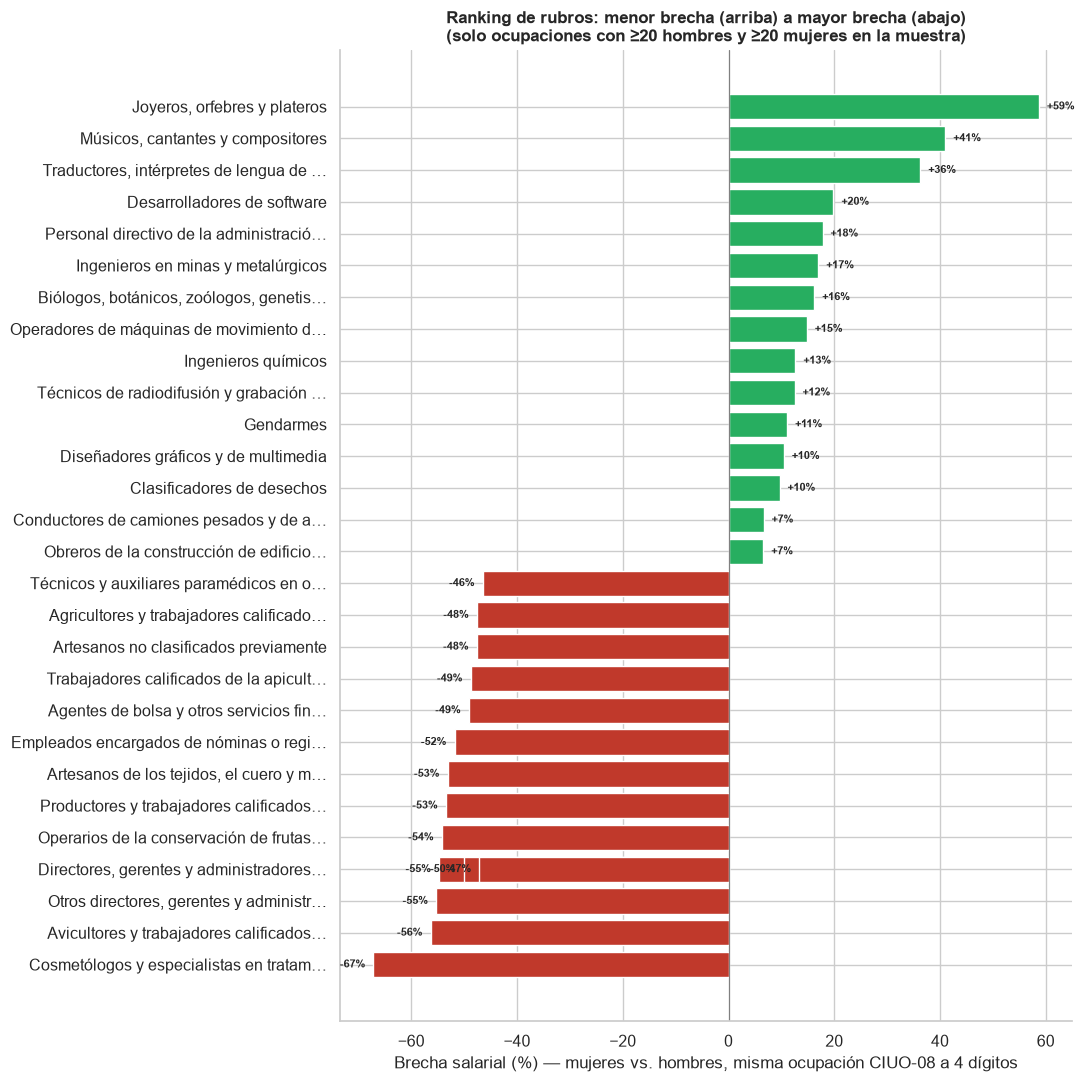

In [6]:
top_bajo = df_ocup.head(15)
top_alto = df_ocup.tail(15)
ranking = pd.concat([top_bajo, top_alto]).drop_duplicates(subset='oficio4_08').sort_values('brecha_pct')

fig, ax = plt.subplots(figsize=(11, 11))
colores = ['#c0392b' if v < 0 else '#27ae60' for v in ranking['brecha_pct']]
etiquetas_y = [f"{n[:38]}{'…' if len(n)>38 else ''}" for n in ranking['nombre']]
bars = ax.barh(etiquetas_y, ranking['brecha_pct'], color=colores, edgecolor='white')
for bar, v, n in zip(bars, ranking['brecha_pct'], ranking['n']):
    ax.text(v + (1.5 if v>=0 else -1.5), bar.get_y()+bar.get_height()/2, f'{v:+.0f}%',
            va='center', ha='left' if v>=0 else 'right', fontsize=8, fontweight='bold')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Brecha salarial (%) — mujeres vs. hombres, misma ocupación CIUO-08 a 4 dígitos')
ax.set_title('Ranking de rubros: menor brecha (arriba) a mayor brecha (abajo)\n(solo ocupaciones con ≥20 hombres y ≥20 mujeres en la muestra)',
             fontsize=12, fontweight='bold')
sns.despine(); plt.tight_layout()
plt.savefig('outputs/figures/ranking_brecha_ocupacion.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación

Con nombres reales y un umbral más estricto (mínimo 20 hombres y 20 mujeres por ocupación, para evitar los casos de muestra muy desbalanceada de la vista exploratoria anterior), este ranking muestra rubros donde la brecha es chica o incluso favorable a mujeres, y otros donde es enorme — **comparando exactamente la misma ocupación de 4 dígitos**, no una categoría amplia que mezcle profesiones distintas.

Esto es lo más cerca que se puede llegar, con datos públicos chilenos, a responder "¿en qué trabajo específico se paga más parejo entre hombres y mujeres, y en cuál la brecha es mayor?"

## 4. Ranking de controles: ¿cuál explica más de la brecha?

La sección 2 mostró que ocupación granular reduce la brecha ajustada, pero no cuánto pesa **cada variable por separado**. Aplicamos la misma descomposición de Oaxaca-Blinder del notebook 07 — ahora con ocupación a 4 dígitos en vez de sector/categoría ocupacional — para rankear qué controles explican más de la diferencia total.

In [7]:
formula_sin_sexo = 'log_ingreso ~ edad + edad2 + C(nivel_grp) + o10 + C(oficio4_grp) + C(anio)'

hombres = muestra[muestra['mujer']==0]
mujeres = muestra[muestra['mujer']==1]

mod_h = smf.wls(formula_sin_sexo, data=hombres, weights=hombres['expr']).fit()
mod_m = smf.wls(formula_sin_sexo, data=mujeres, weights=mujeres['expr']).fit()

y_h, X_h = patsy.dmatrices(formula_sin_sexo, hombres, return_type='dataframe')
y_m, X_m = patsy.dmatrices(formula_sin_sexo, mujeres, return_type='dataframe')

w_h, w_m = hombres['expr'].values, mujeres['expr'].values
xbar_h = np.average(X_h, axis=0, weights=w_h)
xbar_m = np.average(X_m, axis=0, weights=w_m)
beta_h = mod_h.params.reindex(X_h.columns).values

log_ing_h = np.average(y_h.values.flatten(), weights=w_h)
log_ing_m = np.average(y_m.values.flatten(), weights=w_m)
gap_total = log_ing_h - log_ing_m

diff = xbar_h - xbar_m
contrib = diff * beta_h
contrib_df = pd.DataFrame({'variable': X_h.columns, 'contribucion': contrib})

def familia(v):
    if 'nivel_grp' in v: return 'Educación'
    if 'oficio4_grp' in v: return 'Ocupación (4 dígitos)'
    if 'anio' in v: return 'Año'
    if v in ('edad', 'edad2'): return 'Edad (experiencia)'
    if v == 'o10': return 'Horas trabajadas'
    return 'Intercepto'

contrib_df['familia'] = contrib_df['variable'].map(familia)
explicado_total = contrib_df['contribucion'].sum() - contrib_df.loc[contrib_df['familia']=='Intercepto','contribucion'].sum()
no_explicado = gap_total - contrib_df['contribucion'].sum()

resumen_familia = (contrib_df[contrib_df['familia']!='Intercepto'].groupby('familia')['contribucion'].sum() / gap_total * 100)
resumen_familia['No explicado (discriminación/retornos distintos)'] = no_explicado / gap_total * 100
resumen_familia = resumen_familia.sort_values()

print(f'Brecha total (log): {gap_total:.4f}  =  {(1-np.exp(-gap_total))*100:.1f}%')
print()
print('=== Ranking de controles: % de la brecha total que explica cada uno ===')
print(resumen_familia.round(1))

Brecha total (log): 0.2548  =  22.5%

=== Ranking de controles: % de la brecha total que explica cada uno ===
familia
Educación                                          -10.70
Edad (experiencia)                                  -1.60
Año                                                 -0.40
Horas trabajadas                                    12.70
Ocupación (4 dígitos)                               22.20
No explicado (discriminación/retornos distintos)    77.80
Name: contribucion, dtype: float64


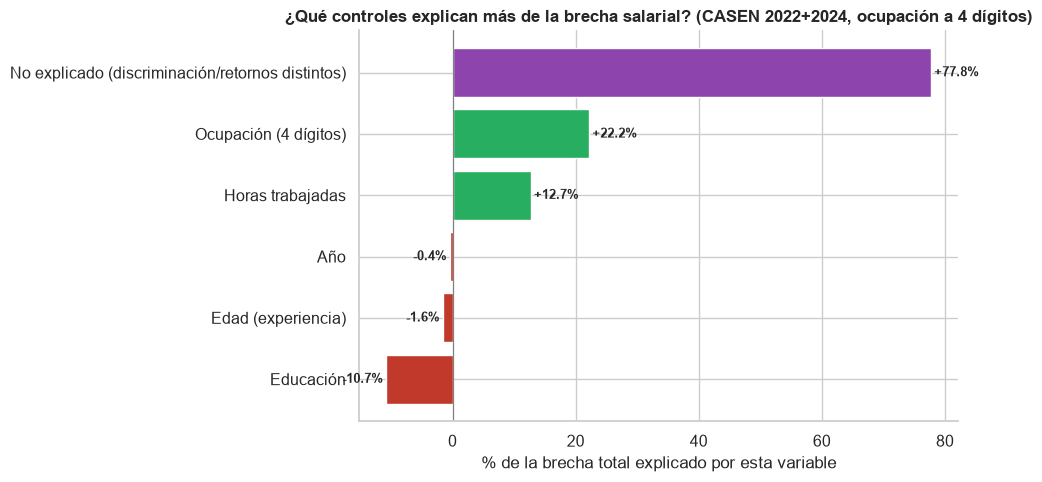

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
colores_r = ['#8e44ad' if 'No explicado' in i else ('#27ae60' if v>=0 else '#c0392b') for i, v in resumen_familia.items()]
ax.barh(resumen_familia.index, resumen_familia.values, color=colores_r, edgecolor='white')
for i, v in enumerate(resumen_familia.values):
    ax.text(v + (0.5 if v>=0 else -0.5), i, f'{v:+.1f}%', va='center',
            ha='left' if v>=0 else 'right', fontsize=9, fontweight='bold')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('% de la brecha total explicado por esta variable')
ax.set_title('¿Qué controles explican más de la brecha salarial? (CASEN 2022+2024, ocupación a 4 dígitos)',
             fontsize=12, fontweight='bold')
sns.despine(); plt.tight_layout()
plt.savefig('outputs/figures/ranking_controles_oaxaca.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretación

El ranking es claro: **Ocupación (4 dígitos) explica 22.2% de la brecha total** — por lejos el mayor factor de composición, muy por delante de **Horas trabajadas (12.7%)**. **Educación aporta -10.7%**, es decir, juega en sentido contrario: las mujeres de la muestra están en promedio mejor educadas, lo que por sí solo predeciría un ingreso *mayor* para ellas (mismo patrón que ya se vio con datos ESI en el notebook 07). Edad y año son prácticamente irrelevantes.

Aun sumando todo lo que sí se explica, **77.8% de la brecha total queda sin explicar** — ni siquiera el control más fino disponible en datos públicos chilenos (ocupación a 4 dígitos) logra explicar la mayoría de la diferencia salarial entre hombres y mujeres.

## Conclusiones

1. **La brecha no desaparece ni siquiera dentro de la misma ocupación de 4 dígitos** — persiste en médicos, enfermeros y técnicos por igual, aunque con magnitudes distintas
2. **Comparar controlando por ocupación amplia vs. granular, con los mismos datos**, aísla el efecto puro de la granularidad — la sección 2 cuantifica exactamente cuánto de la brecha "no explicada" de los notebooks 06-07 se debía a que el 1 dígito no distinguía especialidades dentro de "Profesionales" y categorías similares
3. **El ranking de controles (sección 4) muestra que, incluso con el control más fino disponible, la mayoría de la brecha sigue sin explicarse** — la ocupación granular es el mayor factor de composición identificado, pero está lejos de cerrar la brecha por sí sola
4. **Límite de esta extensión:** no se pudo incluir 2017 (usa CIUO-88, no CIUO-08) ni comparar directamente con los coeficientes de ESI (fuente de datos, años y definición de ingreso distintos) — la comparación rigurosa es la interna de este notebook, no un cruce entre repositorios
5. **Complementa** a `empleabilidad-formacion-casen-chile`: mismo tipo de hallazgo (agregar granularidad revela heterogeneidad oculta), ahora aplicado a la brecha salarial de género en vez de a la empleabilidad por área de formación